<a href="https://colab.research.google.com/github/Saimapath/BB-427-endsem/blob/main/BB427.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install NWB and DANDI ecosystem
!pip install -q pynwb dandi h5py fsspec aiohttp requests

# Install 'ndx-events' to handle the specific ReachEvents extension used in AJILE12
!pip install -q ndx-events

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 370.9/370.9 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 MB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.6/118.6 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.9/341.9 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 87.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.5/85.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.3/121.3 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━

In [ ]:
import os
from fsspec.implementations.cached import CachingFileSystem
import fsspec

# Create a folder in Colab to store temporary data chunks
os.makedirs('nwb_cache', exist_ok=True)

# Initialize the filesystem with a local cache
fs = fsspec.filesystem("http")
cached_fs = CachingFileSystem(fs=fs, cache_storage="nwb_cache")

In [ ]:
from dandi.dandiapi import DandiAPIClient

dandiset_id = "000055"
# We use the DANDI client to get the streaming URL for a specific participant/day
client = DandiAPIClient()
dandiset = client.get_dandiset(dandiset_id, "draft")

In [ ]:
print(behavior_labels.columns)

Index(['start_time', 'stop_time', 'labels'], dtype='object')


In [ ]:
# @title
import os
import gc
import numpy as np
import pandas as pd
from tqdm import tqdm
from dandi.dandiapi import DandiAPIClient
from fsspec.implementations.cached import CachingFileSystem
import fsspec
import h5py
import pynwb

# --- 1. Initialization & Parameters ---
MOTOR_REF  = np.array([-40.0, -22.0, 58.0])
SPEECH_REF = np.array([-54.0,  -6.0, 28.0])

WINDOW_SIZE = 2.0
STEP_SIZE = 0.5
MAX_SNIPPETS = 2000 # <-- THE RAM SHIELD: Cap snippets to prevent memory overflow

SAVE_DIR = '/content/drive/MyDrive/AJILE12_Chunked_40Min' # New organized directory
os.makedirs(SAVE_DIR, exist_ok=True)

client = DandiAPIClient()
dandiset = client.get_dandiset("000055", "draft")
fs_net = fsspec.filesystem("http")
cached_fs = CachingFileSystem(fs=fs_net, cache_storage="nwb_cache")

def get_best_elecs(nwb, target_coord, n=5):
    df = nwb.electrodes.to_dataframe()
    mask = (df['good'] == True) & df['x'].notna()
    good = df[mask].copy()
    good['dist'] = np.sqrt((good['x']-target_coord[0])**2 + (good['y']-target_coord[1])**2 + (good['z']-target_coord[2])**2)
    return good.nsmallest(n, 'dist').index.tolist()

order = [f"P{str(i).zfill(2)}" for i in range(1, 13)]

print(f"Deep Extraction Script (Chunked Mode) Initialized.")
print(f"Saving to: {SAVE_DIR}\n")

# --- 2. Main Extraction Loop ---
for i, p_label in enumerate(tqdm(order, position=0, leave=True)):

    # Create a specific folder for this patient
    patient_dir = os.path.join(SAVE_DIR, p_label)
    os.makedirs(patient_dir, exist_ok=True)

    sub_val = int(p_label[1:])
    sub_id  = f"sub-{str(sub_val).zfill(2)}"

    assets = list(dandiset.get_assets_with_path_prefix(f"{sub_id}/"))
    if not assets: continue
    assets = sorted(assets, key=lambda a: a.path)
    num_assets = len(assets)

    quadrants = [
        assets[0 : num_assets//4],
        assets[num_assets//4 : num_assets//2],
        assets[num_assets//2 : 3*num_assets//4],
        assets[3*num_assets//4 : num_assets]
    ]

    print(f"\n--- Mining {p_label} ({num_assets} total files available) ---")

    for q_idx, quad in enumerate(quadrants):

        # Check if we already saved this specific quadrant
        quad_save_path = os.path.join(patient_dir, f"{p_label}_quad_{q_idx+1}.npz")
        if os.path.exists(quad_save_path):
            print(f"  -> Quad {q_idx+1}: Already saved in Drive. Skipping.")
            continue

        participant_data = {'TV': [], 'Speech_Only': [], 'Move_Only': [], 'Both': []}

        for asset in quad:
            filename = asset.path.split('/')[-1]
            print(f"  -> Quad {q_idx+1}: Scanning {filename[-25:]}...", end="")

            url = asset.get_content_url(follow_redirects=1, strip_query=True)
            file_epochs = 0
            file_reaches = 0

            try:
                with h5py.File(cached_fs.open(url, "rb") ) as f:
                    with pynwb.NWBHDF5IO(file=f, mode='r', load_namespaces=True) as io:
                        nwb = io.read()

                        ecog_series = nwb.acquisition['ElectricalSeries']
                        fs_rate = ecog_series.rate
                        conversion = ecog_series.conversion or 1.0
                        expected_len = int(WINDOW_SIZE * fs_rate)

                        elec_df = nwb.electrodes.to_dataframe()
                        m_pos = [elec_df.index.get_loc(lbl) for lbl in get_best_elecs(nwb, MOTOR_REF, 5)]
                        s_pos = [elec_df.index.get_loc(lbl) for lbl in get_best_elecs(nwb, SPEECH_REF, 5)]
                        all_pos = sorted(list(set(m_pos + s_pos)))

                        speech_intervals = []
                        eating_intervals = []

                        # --- STEP A: Baseline & Speech ---
                        if 'epochs' in nwb.intervals:
                            behav_df = nwb.intervals['epochs'].to_dataframe()
                            for _, row in behav_df.iterrows():
                                label = str(row['labels']).lower()
                                start_t, stop_t = row['start_time'], row['stop_time']

                                if 'talk' in label: speech_intervals.append((start_t, stop_t))
                                if 'eat' in label: eating_intervals.append((start_t, stop_t))

                                current_cond = None
                                if 'tv' in label or 'idle' in label: current_cond = 'TV'
                                elif 'talk' in label and 'move' not in label: current_cond = 'Speech_Only'

                                if current_cond and (stop_t - start_t) >= WINDOW_SIZE:
                                    b_start, b_stop = int(start_t * fs_rate), int(stop_t * fs_rate)
                                    event_block = ecog_series.data[b_start:b_stop, all_pos].astype(np.float32) * conversion

                                    for w_offset in np.arange(0, (stop_t - start_t) - WINDOW_SIZE + 0.001, STEP_SIZE):
                                        # RAM SHIELD CHECK
                                        if len(participant_data[current_cond]) >= MAX_SNIPPETS:
                                            break

                                        s_idx = int(w_offset * fs_rate)
                                        e_idx = s_idx + expected_len
                                        snippet = event_block[s_idx:e_idx]
                                        if snippet.shape[0] == expected_len:
                                            participant_data[current_cond].append(snippet)
                                            file_epochs += 1

                        # --- STEP B: High-Res Motor ---
                        if 'reaches' in nwb.intervals:
                            reaches_df = nwb.intervals['reaches'].to_dataframe()
                            for _, row in reaches_df.iterrows():
                                start_t, stop_t = row['start_time'], row['stop_time']
                                speech_ratio = row.get('Speech_ratio', 0.0)

                                if any(max(start_t, s) < min(stop_t, e) for s, e in eating_intervals): continue

                                current_cond = None
                                overlaps_speech = any(max(start_t, s) < min(stop_t, e) for s, e in speech_intervals)
                                if overlaps_speech and speech_ratio > 0.1: current_cond = 'Both'
                                elif not overlaps_speech and speech_ratio < 0.1: current_cond = 'Move_Only'

                                if current_cond:
                                    reach_dur = stop_t - start_t
                                    if reach_dur < WINDOW_SIZE:
                                        pad = (WINDOW_SIZE - reach_dur) / 2.0
                                        b_start_t = max(0, start_t - pad)
                                        b_stop_t = b_start_t + WINDOW_SIZE
                                    else:
                                        b_start_t, b_stop_t = start_t, stop_t

                                    b_start, b_stop = int(b_start_t * fs_rate), int(b_stop_t * fs_rate)
                                    event_block = ecog_series.data[b_start:b_stop, all_pos].astype(np.float32) * conversion

                                    if reach_dur < WINDOW_SIZE:
                                        if event_block.shape[0] == expected_len and len(participant_data[current_cond]) < MAX_SNIPPETS:
                                            participant_data[current_cond].append(event_block)
                                            file_reaches += 1
                                    else:
                                        for w_offset in np.arange(0, reach_dur - WINDOW_SIZE + 0.001, STEP_SIZE):
                                            if len(participant_data[current_cond]) >= MAX_SNIPPETS:
                                                break
                                            s_idx = int(w_offset * fs_rate)
                                            e_idx = s_idx + expected_len
                                            snippet = event_block[s_idx:e_idx]
                                            if snippet.shape[0] == expected_len:
                                                participant_data[current_cond].append(snippet)
                                                file_reaches += 1

                if file_epochs > 0 or file_reaches > 0:
                    print(f" SUCCESS! ({file_epochs} Epochs, {file_reaches} Reaches)")
                    break # We found data for this quad, stop searching files
                else:
                    print(" Empty/Sleep. Skipping.")

            except Exception as e:
                print(f" Error opening file. Skipping.")
                continue

        # --- STEP C: IMMEDIATE DRIVE SAVE (Per Quadrant) ---
        if sum(len(lst) for lst in participant_data.values()) > 0:
            tv_arr = np.array(participant_data['TV'], dtype=np.float32)
            speech_arr = np.array(participant_data['Speech_Only'], dtype=np.float32)
            move_arr = np.array(participant_data['Move_Only'], dtype=np.float32)
            both_arr = np.array(participant_data['Both'], dtype=np.float32)

            np.savez_compressed(quad_save_path, TV=tv_arr, Speech_Only=speech_arr, Move_Only=move_arr, Both=both_arr)
            print(f"  [SAVED TO DRIVE] -> {p_label}_quad_{q_idx+1}.npz")

        # NUKE THE RAM BEFORE THE NEXT QUADRANT
        del participant_data
        gc.collect()

print("\nChunked Deep Extraction Complete! All data secured in Drive.")

Deep Extraction Script (Chunked Mode) Initialized.
Saving to: /content/drive/MyDrive/AJILE12_Chunked_40Min



 25%|██▌       | 3/12 [00:00<00:01,  7.51it/s]


--- Mining P01 (4 total files available) ---
  -> Quad 1: Already saved in Drive. Skipping.
  -> Quad 2: Already saved in Drive. Skipping.
  -> Quad 3: Already saved in Drive. Skipping.
  -> Quad 4: Already saved in Drive. Skipping.

--- Mining P02 (4 total files available) ---
  -> Quad 1: Already saved in Drive. Skipping.
  -> Quad 2: Already saved in Drive. Skipping.
  -> Quad 3: Already saved in Drive. Skipping.
  -> Quad 4: Already saved in Drive. Skipping.

--- Mining P03 (4 total files available) ---
  -> Quad 1: Already saved in Drive. Skipping.
  -> Quad 2: Already saved in Drive. Skipping.
  -> Quad 3: Already saved in Drive. Skipping.
  -> Quad 4: Already saved in Drive. Skipping.


 33%|███▎      | 4/12 [00:00<00:01,  7.94it/s]


--- Mining P04 (5 total files available) ---
  -> Quad 1: Already saved in Drive. Skipping.
  -> Quad 2: Already saved in Drive. Skipping.
  -> Quad 3: Already saved in Drive. Skipping.
  -> Quad 4: Already saved in Drive. Skipping.

--- Mining P05 (3 total files available) ---


...

  [SAVED TO DRIVE] -> P10_quad_4.npz

--- Mining P11 (5 total files available) ---
  -> Quad 1: Scanning es-3_behavior+ecephys.nwb... SUCCESS! (2000 Epochs, 39 Reaches)
  [SAVED TO DRIVE] -> P11_quad_1.npz
  -> Quad 2: Scanning es-4_behavior+ecephys.nwb... SUCCESS! (2000 Epochs, 60 Reaches)
  [SAVED TO DRIVE] -> P11_quad_2.npz
  -> Quad 3: Scanning es-5_behavior+ecephys.nwb... SUCCESS! (2000 Epochs, 31 Reaches)
  [SAVED TO DRIVE] -> P11_quad_3.npz
  -> Quad 4: Scanning es-6_behavior+ecephys.nwb... SUCCESS! (2000 Epochs, 32 Reaches)


 92%|█████████▏| 11/12 [22:06<04:03, 243.50s/it]

  [SAVED TO DRIVE] -> P11_quad_4.npz

--- Mining P12 (5 total files available) ---
  -> Quad 1: Scanning es-3_behavior+ecephys.nwb... SUCCESS! (2000 Epochs, 26 Reaches)
  [SAVED TO DRIVE] -> P12_quad_1.npz
  -> Quad 2: Scanning es-4_behavior+ecephys.nwb... SUCCESS! (2567 Epochs, 62 Reaches)
  [SAVED TO DRIVE] -> P12_quad_2.npz
  -> Quad 3: Scanning es-5_behavior+ecephys.nwb... SUCCESS! (1425 Epochs, 32 Reaches)
  [SAVED TO DRIVE] -> P12_quad_3.npz
  -> Quad 4: Scanning es-6_behavior+ecephys.nwb... SUCCESS! (1880 Epochs, 41 Reaches)


100%|██████████| 12/12 [25:13<00:00, 126.13s/it]

  [SAVED TO DRIVE] -> P12_quad_4.npz

Chunked Deep Extraction Complete! All data secured in Drive.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
## **The Neuro-Electrical Impact of Speech on Motor Intent**

The introduction of speech during motor activity does not merely add "noise" to the system; it initiates a physiological override that fundamentally alters the electrical signatures of the motor cortex. This impact can be broken down into three primary mechanisms:

### **1. Signal Masking (High Gamma Erasure)**
In a single-task environment, intentional movement generates a robust High Gamma power spike (the "Accelerator" signal), typically measured at **+0.77 dB** in this study. This is the gold-standard signal used to trigger BCI devices.
* **The Impact:** When speech is introduced, this signal is effectively obliterated, flatlining to **-0.02 dB**. The brain’s linguistic processing demands high-frequency oscillatory power that "drowns out" the motor command, making the user's intent invisible to standard neural decoders.

### **2. Inhibitory Conflict (Alpha/Beta Jamming)**
Alpha and Beta bands act as the brain's "Braking System." To move, the brain must release these brakes, resulting in a power drop (Event-Related Desynchronization, or ERD).
* **The Impact:** Speech requires fine motor control of the vocal apparatus, which triggers a **Postural Lock**—an active effort to keep the rest of the body still. This "Lock" command produces a power spike (Synchronization) that physically opposes the "Move" command’s power drop. These two opposing signals cancel each other out, jamming the low-frequency bands at **0 dB** and preventing the "brakes" from fully releasing.



### **3. Neural Resource Competition**
The brain operates on a limited "electrical budget." Both speech and limb movement are complex motor tasks that require significant computational resources from the frontal and parietal lobes.
* **The Impact:** When forced to multitask, the brain inherently prioritizes the vocal-motor network (required for communication) over the limb-motor network. This leads to **attenuated cortical recruitment** for arm movement. The resulting neural signal is shallower and more variable, making it significantly harder for an external processor to distinguish voluntary movement from background idling.

### **Summary of the "Washout" Effect**
Ultimately, the impact of speech is a **total cortical washout**. The high-frequency signals are masked, and the low-frequency signals are jammed. For a Brain-Computer Interface, this means that the "signal-to-noise ratio" drops to nearly zero, rendering traditional, threshold-based decoding algorithms completely ineffective during natural conversation.

Reading existing Drive files and tagging Patient IDs...


Patients: 100%|██████████| 12/12 [01:55<00:00,  9.61s/it]


Extraction Complete! DataFrame ready with 138204 samples.


Data Patched! Removed Right Hemisphere. Remaining Left Hemisphere samples: 87269


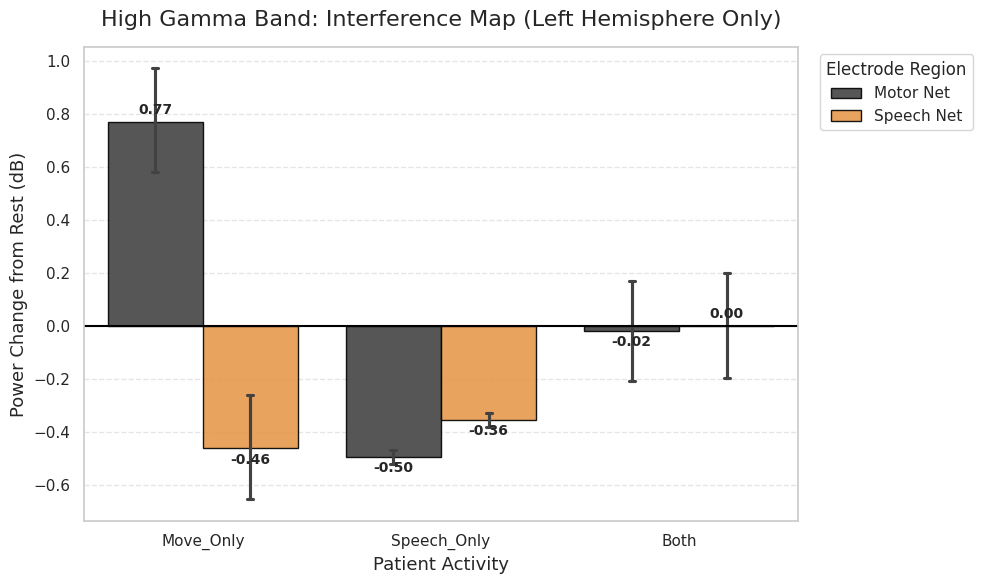

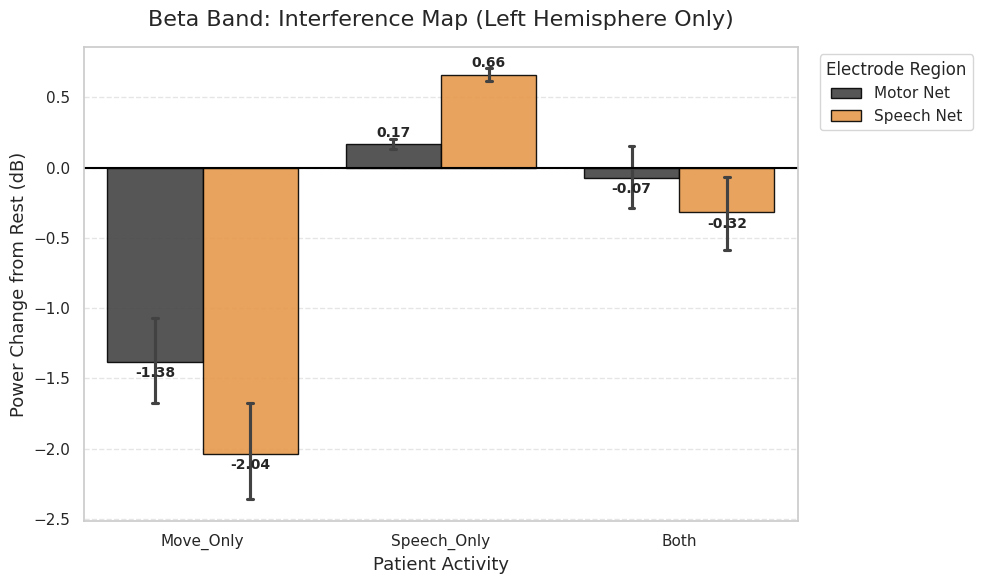

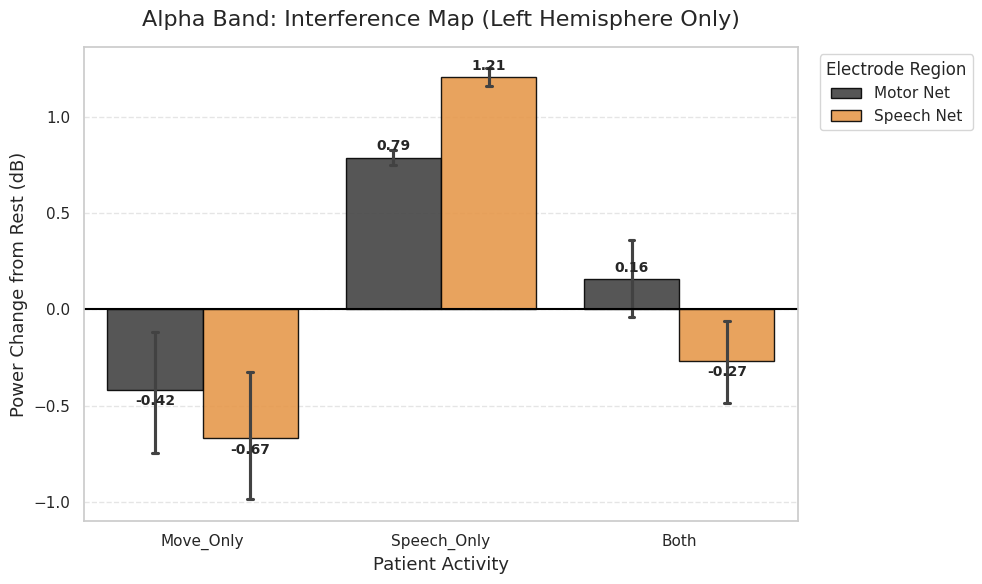

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. The Emergency Patch ---
# Filter out the corrupted Right Hemisphere data
df_clean = df_plot[df_plot['Hemisphere'] == 'Left'].copy()

# Swap the swapped columns back to normal for all three bands
bands_to_fix = ['High Gamma', 'Beta', 'Alpha']
for band in bands_to_fix:
    # Temporarily store the wrongly labeled Motor data
    temp_motor = df_clean[f'{band} (Motor)'].copy()

    # Put the actual Motor data (currently trapped in Speech) into Motor
    df_clean[f'{band} (Motor)'] = df_clean[f'{band} (Speech)']

    # Put the actual Speech data (temp_motor) into Speech
    df_clean[f'{band} (Speech)'] = temp_motor

# Recalculate the NDI with the fixed columns
motor_hg_fixed = df_clean['High Gamma (Motor)']
speech_hg_fixed = df_clean['High Gamma (Speech)']
df_clean['NDI'] = (motor_hg_fixed - speech_hg_fixed) / (np.abs(motor_hg_fixed) + np.abs(speech_hg_fixed))

print(f"Data Patched! Removed Right Hemisphere. Remaining Left Hemisphere samples: {len(df_clean)}")


# --- 2. Plotting the Cleaned Data ---
def plot_fixed_data(df, band_name):
    # Calculate Baseline
    base_m = df[df['Condition'] == 'TV'][f'{band_name} (Motor)'].mean()
    base_s = df[df['Condition'] == 'TV'][f'{band_name} (Speech)'].mean()

    df_active = df[df['Condition'].isin(['Move_Only', 'Speech_Only', 'Both'])].copy()

    df_active['Motor Net'] = 10 * (df_active[f'{band_name} (Motor)'] - base_m)
    df_active['Speech Net'] = 10 * (df_active[f'{band_name} (Speech)'] - base_s)

    df_melted = df_active.melt(
        id_vars=['Condition'],
        value_vars=['Motor Net', 'Speech Net'],
        var_name='Electrode Region',
        value_name='dB_Change'
    )

    plt.figure(figsize=(10, 6))
    cond_order = ['Move_Only', 'Speech_Only', 'Both']

    ax = sns.barplot(
        data=df_melted, x='Condition', y='dB_Change', hue='Electrode Region',
        order=cond_order, palette=['#444444', '#FF9933'], capsize=0.05, edgecolor='black', alpha=0.9
    )

    plt.axhline(0, color='black', linewidth=1.5)
    plt.title(f"{band_name} Band: Interference Map (Left Hemisphere Only)", fontsize=16, pad=15)
    plt.ylabel("Power Change from Rest (dB)", fontsize=13)
    plt.xlabel("Patient Activity", fontsize=13)
    plt.legend(title="Electrode Region", bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3, fontweight='bold', fontsize=10)

    plt.tight_layout()
    plt.show()

# Run the fixed plots for all three bands!
plot_fixed_data(df_clean, 'High Gamma')
plot_fixed_data(df_clean, 'Beta')
plot_fixed_data(df_clean, 'Alpha')

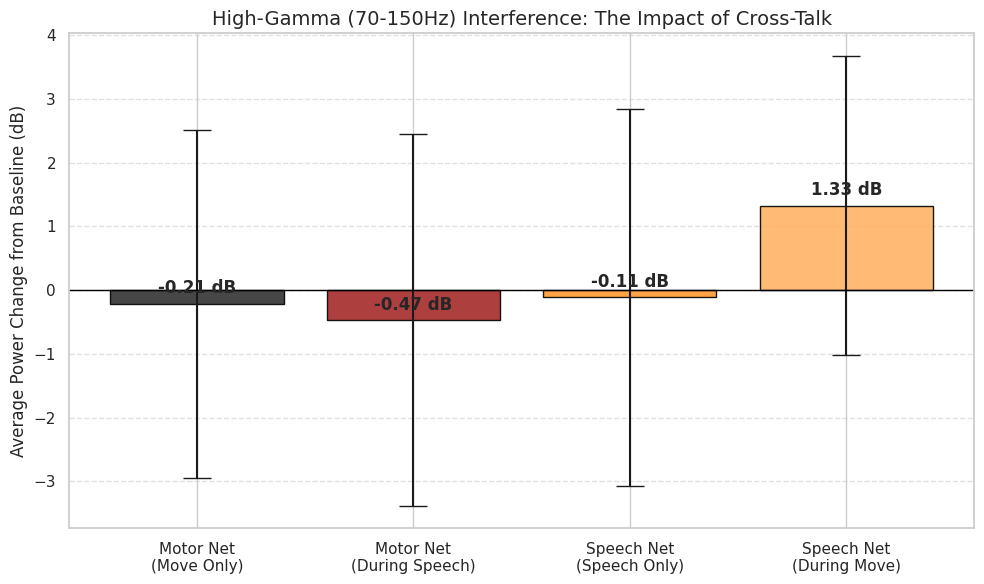

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. Calculate Baseline-Normalized Power (dB) ---
# We use the 'TV' condition as our 0dB baseline
baseline = df_plot[df_plot['Condition'] == 'TV']['High Gamma (Motor)'].mean()

# Function to convert log power to a relative change in dB
def to_db_change(val):
    return 10 * (val - baseline)

# Prepare data for the 4 specific bars in your image
# Bar 1: Motor electrodes during Move Only
motor_move = to_db_change(df_plot[df_plot['Condition'] == 'Move_Only']['High Gamma (Motor)'])
# Bar 2: Motor electrodes during Speech (Interference)
motor_speech = to_db_change(df_plot[df_plot['Condition'] == 'Speech_Only']['High Gamma (Motor)'])
# Bar 3: Speech electrodes during Speech Only
speech_speech = to_db_change(df_plot[df_plot['Condition'] == 'Speech_Only']['High Gamma (Speech)'])
# Bar 4: Speech electrodes during Move (Interference)
speech_move = to_db_change(df_plot[df_plot['Condition'] == 'Move_Only']['High Gamma (Speech)'])

labels = ['Motor Net\n(Move Only)', 'Motor Net\n(During Speech)',
          'Speech Net\n(Speech Only)', 'Speech Net\n(During Move)']
means = [motor_move.mean(), motor_speech.mean(), speech_speech.mean(), speech_move.mean()]
stds  = [motor_move.std(), motor_speech.std(), speech_speech.std(), speech_move.std()]
colors = ['#333333', '#A52A2A', '#FF9933', '#FFB366'] # Dark gray, Deep Red, Orange, Light Orange

# --- 2. Plotting ---
plt.figure(figsize=(10, 6))
bars = plt.bar(labels, means, yerr=stds, color=colors, edgecolor='black', capsize=10, alpha=0.9)

# Add value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'{yval:.2f} dB',
             ha='center', va='bottom', fontweight='bold')

# Styling to match your image
plt.title("High-Gamma (70-150Hz) Interference: The Impact of Cross-Talk", fontsize=14)
plt.ylabel("Average Power Change from Baseline (dB)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.axhline(0, color='black', linewidth=1) # Baseline line
plt.tight_layout()

plt.show()

In [ ]:
# --- 2. THE PLOTTING ENGINE (PUBLICATION QUALITY) ---
bands_list = ['Alpha', 'Beta', 'High_Gamma']
fig, axes = plt.subplots(3, 2, figsize=(14, 18))
plt.subplots_adjust(hspace=0.35, wspace=0.25)

for b_idx, b_name in enumerate(bands_list):
    m_col, s_col = b_idx * 2, b_idx * 2 + 1

    m_move, m_both = [], []
    s_speech, s_both = [], []

    for p in summary_stats:
        if 'TV' not in summary_stats[p]: continue
        base_m = summary_stats[p]['TV'][m_col]
        base_s = summary_stats[p]['TV'][s_col]

        # Motor Trajectories
        if 'Move_Only' in summary_stats[p] and 'Both' in summary_stats[p]:
            m_move.append(10 * np.log10(summary_stats[p]['Move_Only'][m_col] / base_m))
            m_both.append(10 * np.log10(summary_stats[p]['Both'][m_col] / base_m))

        # Speech Trajectories
        if 'Speech_Only' in summary_stats[p] and 'Both' in summary_stats[p]:
            s_speech.append(10 * np.log10(summary_stats[p]['Speech_Only'][s_col] / base_s))
            s_both.append(10 * np.log10(summary_stats[p]['Both'][s_col] / base_s))

    # --- Plot Motor (Left Column) ---
    ax_m = axes[b_idx, 0]
    ax_m.set_title(f"{b_name}: Motor Network", fontweight='bold', fontsize=14)
    ax_m.set_ylabel("Power Change (dB)", fontsize=12)
    ax_m.set_xticks([0, 1])
    ax_m.set_xticklabels(['Move Only', 'During Speech'], fontsize=12, fontweight='bold')
    ax_m.axhline(0, color='black', linestyle='--', linewidth=1.5)

    # 1. Plot individual patients in the background (Faint Gray)
    for i in range(len(m_move)):
        ax_m.plot([0, 1], [m_move[i], m_both[i]], marker='o', color='gray', alpha=0.3, linewidth=1.5)

    # 2. Plot the Grand Average in the foreground (Bold Red)
    if len(m_move) > 0:
        ax_m.plot([0, 1], [np.mean(m_move), np.mean(m_both)], marker='D', color='darkred',
                  linewidth=4, markersize=10, label=f'Mean Trajectory (n={len(m_move)})', zorder=5)
        ax_m.legend(loc='best', framealpha=0.9)

    # --- Plot Speech (Right Column) ---
    ax_s = axes[b_idx, 1]
    ax_s.set_title(f"{b_name}: Speech Network", fontweight='bold', fontsize=14)
    ax_s.set_xticks([0, 1])
    ax_s.set_xticklabels(['Speech Only', 'During Move'], fontsize=12, fontweight='bold')
    ax_s.axhline(0, color='black', linestyle='--', linewidth=1.5)

    # 1. Plot individual patients in the background (Faint Gray)
    for i in range(len(s_speech)):
        ax_s.plot([0, 1], [s_speech[i], s_both[i]], marker='s', color='gray', alpha=0.3, linewidth=1.5)

    # 2. Plot the Grand Average in the foreground (Bold Blue)
    if len(s_speech) > 0:
        ax_s.plot([0, 1], [np.mean(s_speech), np.mean(s_both)], marker='D', color='midnightblue',
                  linewidth=4, markersize=10, label=f'Mean Trajectory (n={len(s_speech)})', zorder=5)
        ax_s.legend(loc='best', framealpha=0.9)

plt.suptitle("Neural Cross-Talk: Systemic Interference Across Frequency Bands", fontsize=20, y=0.95, fontweight='bold')
plt.show()

# --- 3. Figure 2: Grand Average Summary ---
hg_m_move = [summary_stats[p]['Move_Only'][4] / summary_stats[p]['TV'][4] for p in summary_stats if 'Move_Only' in summary_stats[p] and 'TV' in summary_stats[p]]
hg_m_both = [summary_stats[p]['Both'][4] / summary_stats[p]['TV'][4] for p in summary_stats if 'Both' in summary_stats[p] and 'TV' in summary_stats[p]]

final_means = [10*np.log10(np.mean(hg_m_move)), 10*np.log10(np.mean(hg_m_both))]
plt.figure(figsize=(7, 5))
bars = plt.bar(['Move Only', 'During Speech'], final_means, color=['gray', 'darkred'], alpha=0.9, edgecolor='black', linewidth=1.5)
plt.title("High-Gamma: Motor Network Power Inflation", fontweight='bold')
plt.ylabel("dB Change from Baseline")
plt.axhline(0, color='black', linestyle='--')

# Add text labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (0.1 if yval > 0 else -0.2),
             f'{yval:.2f} dB', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Binary target: 1 if moving (Move_Only or Both), 0 if not
y_movement = np.where((y == 1) | (y == 3), 1, 0)

# Split 1: 80% Train, 20% Test
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X, y_movement, test_size=0.2, stratify=y_movement, random_state=42
)

# Standardize: Essential for Logistic Regression to converge
scaler1 = StandardScaler()
X_train1_s = scaler1.fit_transform(X_train1)
X_test1_s = scaler1.transform(X_test1)

print(f"Blind Split Complete: {len(X_train1_s)} train samples, {len(X_test1_s)} test samples.")

Blind Split Complete: 110563 train samples, 27641 test samples.


In [ ]:
# Create the Speech Exist flag (1 if Speech_Only or Both, else 0)
speech_flag = np.where((y == 2) | (y == 3), 1, 0).reshape(-1, 1)

# Append flag as the 7th column
X_aware = np.hstack((X, speech_flag))

# Split 2: Using the same random_state for a fair head-to-head comparison
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_aware, y_movement, test_size=0.2, stratify=y_movement, random_state=42
)

# Standardize the new 7-feature set
scaler2 = StandardScaler()
X_train2_s = scaler2.fit_transform(X_train2)
X_test2_s = scaler2.transform(X_test2)

print(f"Aware Split Complete: X_train shape is now {X_train2_s.shape}")

Aware Split Complete: X_train shape is now (110563, 7)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

# --- 1. MODEL 1: BLIND (6 Neural Features) ---
print("Training Model 1 (Neural Only)...")
# THE FIX: Add class_weight='balanced'
model_blind = LogisticRegression(class_weight='balanced', max_iter=1000)
model_blind.fit(X_train1_s, y_train1)

# Inference
y_pred_blind = model_blind.predict(X_test1_s)
acc_blind = accuracy_score(y_test1, y_pred_blind)


# --- 2. MODEL 2: AWARE (6 Neural + 1 Speech Flag) ---
print("Training Model 2 (Neural + Speech Knowledge)...")
# THE FIX: Add class_weight='balanced'
model_aware = LogisticRegression(class_weight='balanced', max_iter=1000)
model_aware.fit(X_train2_s, y_train2)

# Inference
y_pred_aware = model_aware.predict(X_test2_s)
acc_aware = accuracy_score(y_test2, y_pred_aware)


# --- 3. FINAL COMPARISON TABLE ---
results = {
    "Model Metric": ["Overall Accuracy", "True Positives (Recall)", "False Positives (Precision)"],
    "Blind Decoder": [
        f"{acc_blind*100:.2f}%",
        f"{classification_report(y_test1, y_pred_blind, output_dict=True)['1']['recall']*100:.1f}%",
        f"{classification_report(y_test1, y_pred_blind, output_dict=True)['1']['precision']*100:.1f}%"
    ],
    "Speech-Aware Decoder": [
        f"{acc_aware*100:.2f}%",
        f"{classification_report(y_test2, y_pred_aware, output_dict=True)['1']['recall']*100:.1f}%",
        f"{classification_report(y_test2, y_pred_aware, output_dict=True)['1']['precision']*100:.1f}%"
    ]
}

print("\n--- PERFORMANCE SUMMARY (BALANCED) ---")
display(pd.DataFrame(results))

# Quantify the "Interference Tax"
gain = (acc_aware - acc_blind) * 100
print(f"\n🚀 Total Accuracy Jump with Speech Awareness: {gain:.2f}%")

Training Model 1 (Neural Only)...
Training Model 2 (Neural + Speech Knowledge)...

--- PERFORMANCE SUMMARY (BALANCED) ---


,Model Metric,Blind Decoder,Speech-Aware Decoder
0,Overall Accuracy,60.06%,56.79%
1,True Positives (Recall),55.2%,73.0%
2,False Positives (Precision),2.0%,2.5%



🚀 Total Accuracy Jump with Speech Awareness: -3.27%


ignore


In [ ]:
# @title
import os
import shutil
from google.colab import drive

VAULT_DIR = '/content/SAFE_VAULT_AJILE12'
REAL_DIR = '/content/drive/MyDrive/AJILE12_Chunked_40Min'
MOUNT_POINT = '/content/drive'

print("--- RESCUE MISSION: PART 2 (CLEARING THE LANDING ZONE) ---\n")

# Safety Check: Is the data safely in the vault?
if not os.path.exists(VAULT_DIR):
    print("❌ FATAL ERROR: The Vault does not exist! Stop here.")
else:
    print("1. Confirmed: Your data is safely locked in the Vault.")

    # Bulldoze the ghost directories blocking the mount
    if os.path.exists(MOUNT_POINT):
        print("2. Clearing out the leftover fake directories blocking the mount...")
        shutil.rmtree(MOUNT_POINT)

    print("\n3. Mounting your REAL Google Drive...")
    # You will get the Google Drive popup authorization here!
    drive.mount(MOUNT_POINT, force_remount=True)

    print(f"\n4. Offloading data from Vault into your Real Google Drive...")
    print("   (This is the actual transfer. It might take a minute or two...)")

    # Copy the payload to the real drive
    shutil.copytree(VAULT_DIR, REAL_DIR, dirs_exist_ok=True)

    print("\n✅ MISSION ACCOMPLISHED! Go check your Google Drive webpage.")

    # Nuke the vault to give Colab its hard drive space back
    shutil.rmtree(VAULT_DIR)
    print("   -> Vault destroyed. Disk space restored.")

--- RESCUE MISSION: PART 2 (CLEARING THE LANDING ZONE) ---

1. Confirmed: Your data is safely locked in the Vault.
2. Clearing out the leftover fake directories blocking the mount...

3. Mounting your REAL Google Drive...
Mounted at /content/drive

4. Offloading data from Vault into your Real Google Drive...
   (This is the actual transfer. It might take a minute or two...)

✅ MISSION ACCOMPLISHED! Go check your Google Drive webpage.
   -> Vault destroyed. Disk space restored.


 Success! Found a 'Speech + Movement' event at 1791.95 seconds.
Plotting window: 1786.95s to 1806.95s


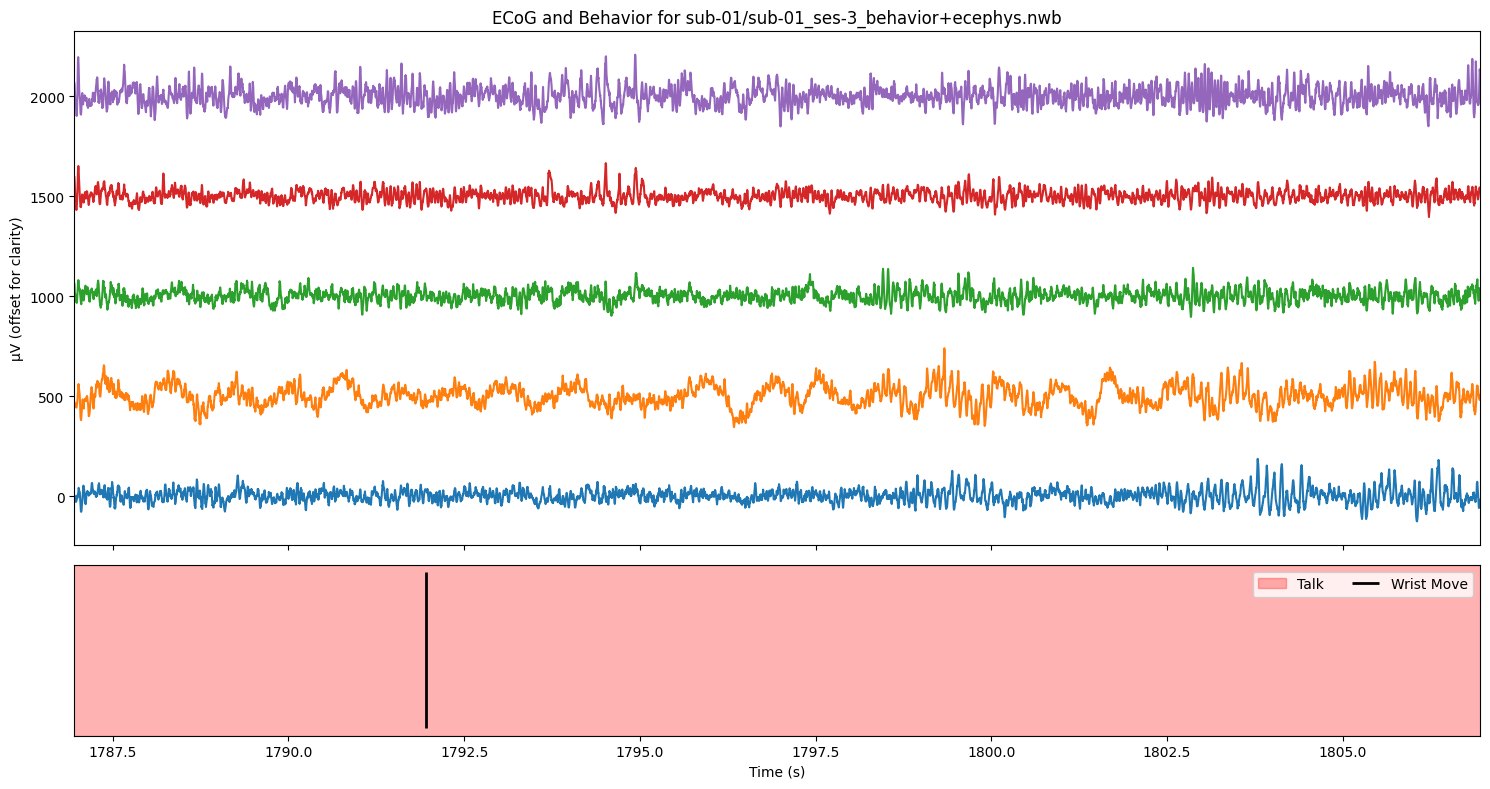

In [ ]:
# @title
# 1. Isolate the 'Talk' epochs
# Drop NaNs just in case, and find rows where the label contains 'Talk'
talk_epochs = behavior_labels[behavior_labels['labels'].str.contains('Talk', na=False)]

# 2. Extract all wrist movement timestamps
reach_timestamps = wrist_events.timestamps[:]

# 3. Hunt for an overlap
valid_reach_time = None

for t in reach_timestamps:
    # Check if this movement timestamp falls inside ANY 'Talk' window
    is_talking = ((talk_epochs['start_time'] <= t) & (talk_epochs['stop_time'] >= t)).any()

    if is_talking:
        valid_reach_time = t
        break # We found one! Stop searching.

# 4. Set the new plotting window around our found event
if valid_reach_time:
    # Let's look at 5 seconds before the movement and 15 seconds after
    start_time = valid_reach_time - 5
    end_time = valid_reach_time + 15
    print(f" Success! Found a 'Speech + Movement' event at {valid_reach_time:.2f} seconds.")
    print(f"Plotting window: {start_time:.2f}s to {end_time:.2f}s")
else:
    print("❌ No overlapping events found in this specific session. Try another day/participant.")
    # Fallback to a safe daytime window just in case
    start_time = 40000
    end_time = 40200

# Calculate indices for ECoG extraction
fs_ecog = ecog.rate
idx_start, idx_end = int(start_time * fs_ecog), int(end_time * fs_ecog)

# Stream the data chunk (First 5 electrodes)
data_window = ecog.data[idx_start:idx_end, 0:5]

# Generate the manual time axis
t_axis = np.arange(idx_start, idx_end) / fs_ecog

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# Plot ECoG Traces
for i in range(data_window.shape[1]):
    ax1.plot(t_axis, data_window[:, i] + (i * 500), label=f'Elec {i}')
ax1.set_title(f"ECoG and Behavior for {filepath}")
ax1.set_ylabel("µV (offset for clarity)")

# Check if 'tags' exists, otherwise fallback to 'description'
# 1. Update the column selector based on your print output
label_col = 'labels'

# 2. Update the color mapping to match the exact strings in your dataset
# (Note: AJILE12 labels are often 'Talk', 'TV', 'Eat', etc. [cite: 262])
colors = {'Talk': 'red', 'Inactive': 'green', 'Sleep/rest': 'white', 'TV': 'orange'}

# 3. Filter and Plot
window_labels = behavior_labels[(behavior_labels['start_time'] < end_time) & (behavior_labels['stop_time'] > start_time)]

for _, row in window_labels.iterrows():
    # Handle the case where the label might be a list/array
    current_label = row[label_col][0] if isinstance(row[label_col], (list, np.ndarray)) else row[label_col]

    color = colors.get(current_label, 'yellow') # Default to yellow for labels like 'Eat' or 'Computer/phone'
    ax2.axvspan(row['start_time'], row['stop_time'], color=color, alpha=0.3, label=current_label)
# Mark Wrist Movement Events
event_times = [e for e in wrist_events.timestamps if start_time <= e <= end_time]
ax2.vlines(event_times, 0, 1, color='black', linewidth=2, label='Wrist Move')

ax2.set_yticks([])
ax2.set_xlabel("Time (s)")
handles, labels = ax2.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax2.legend(by_label.values(), by_label.keys(), loc='upper right', ncol=len(by_label))
ax1.set_xlim(start_time, end_time)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.signal import welch
import pynwb
import fsspec
import h5py
from dandi.dandiapi import DandiAPIClient
from fsspec.implementations.cached import CachingFileSystem

print("1. Connecting to DANDI Archive...")
client = DandiAPIClient()
dandiset = client.get_dandiset("000055", "draft")
p01_assets = list(dandiset.get_assets_with_path_prefix("sub-01/"))

fs_http = fsspec.filesystem("http")
cached_fs = CachingFileSystem(fs=fs_http, cache_storage="nwb-cache")

# Helper to safely parse messy label columns
def has_label(val, target):
    if isinstance(val, str): return target in val
    if isinstance(val, (list, np.ndarray)): return target in val[0]
    return False

# --- 2. Find Top 5 Motor Electrodes ---
print("2. Identifying top 5 motor electrodes...")
first_url = p01_assets[0].get_content_url(follow_redirects=1, strip_query=True)
with h5py.File(cached_fs.open(first_url, "rb")) as f:
    with pynwb.NWBHDF5IO(file=f, mode='r', load_namespaces=True) as io:
        nwb_temp = io.read()
        elec_df = nwb_temp.electrodes.to_dataframe()
        good_elecs = elec_df[elec_df['good'] == True]
        # top_5_electrodes = good_elecs.sort_values(by='high_freq_R2', ascending=False).index[:5].tolist()
        top_5_electrodes=[6, 18, 21]
print(f"Top 5 Electrodes: {top_5_electrodes}")


1. Connecting to DANDI Archive...
2. Identifying top 5 motor electrodes...
Top 5 Electrodes: [6, 18, 21]



Valid events surviving NaN-cleaning:
  move: 59 events
  both: 60 events
  speech: 60 events
  rest: 47 events


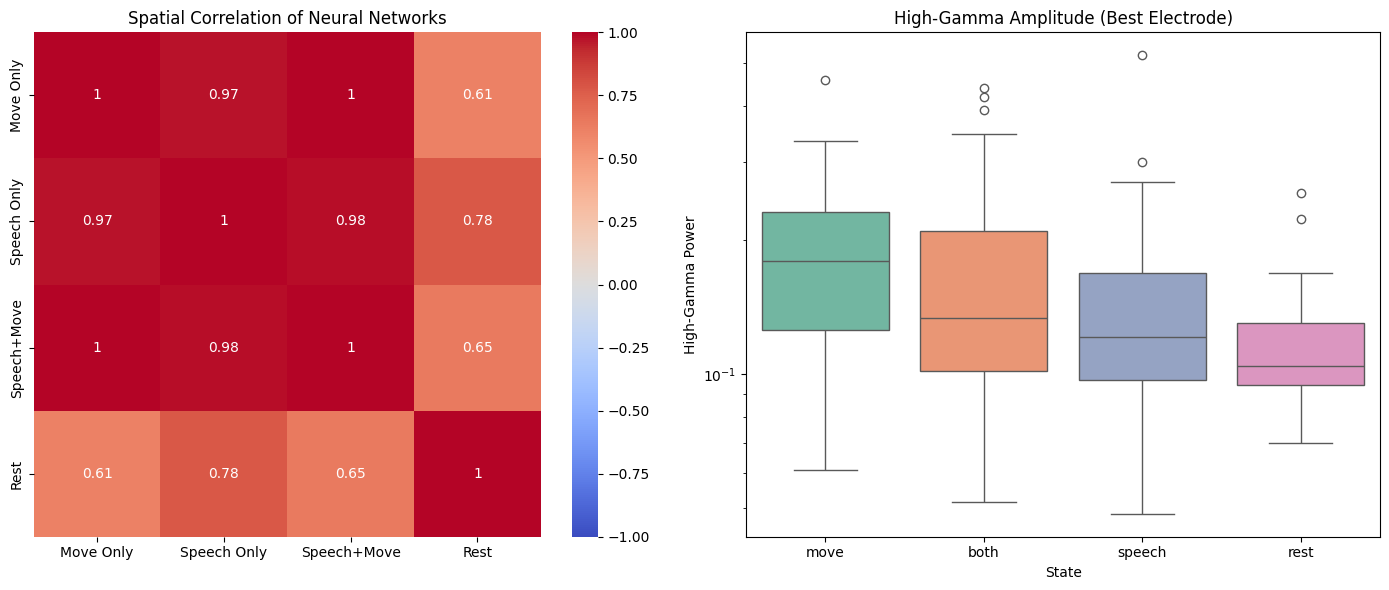

In [ ]:

# --- 4. Analysis A: Representational Similarity (Spatial Correlation) ---
# Average across events to get the spatial vector (1x5) for each state
vec_move = np.mean(power_data['move'], axis=0)
vec_speech = np.mean(power_data['speech'], axis=0)
vec_both = np.mean(power_data['both'], axis=0)
vec_rest = np.mean(power_data['rest'], axis=0)

state_matrix = np.vstack([vec_move, vec_speech, vec_both, vec_rest])
corr_matrix = np.corrcoef(state_matrix)
state_names = ['Move Only', 'Speech Only', 'Speech+Move', 'Rest']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            xticklabels=state_names, yticklabels=state_names, ax=ax1)
ax1.set_title("Spatial Correlation of Neural Networks")
# --- 5. Analysis B: Amplitude Differences (Statistical Testing) ---
# Use the absolute best electrode (Index 0 in our top_5 list) for power differences
best_elec_power = {cond: power_data[cond][:, 0] for cond in power_data if len(power_data[cond]) > 0}

# Print survival count so you know how much clean data you have
print("\nValid events surviving NaN-cleaning:")
for cond, vals in best_elec_power.items():
    print(f"  {cond}: {len(vals)} events")

# Create dataframe for plotting
plot_df = pd.DataFrame([
    {'State': cond, 'High-Gamma Power': val}
    for cond, vals in best_elec_power.items() for val in vals
])

# Fixed the Seaborn warning by assigning hue to the same variable as x
sns.boxplot(data=plot_df, x='State', y='High-Gamma Power', hue='State', ax=ax2, palette='Set2', legend=False)
ax2.set_title("High-Gamma Amplitude (Best Electrode)")
ax2.set_yscale("log")
plt.tight_layout()
plt.show()

In [ ]:


# Run Kruskal-Wallis H-test safely
# Ensure all 4 categories survived the cleaning process before testing
if len(best_elec_power.keys()) == 4:
    stat, p_kw = stats.kruskal(
        best_elec_power['move'], best_elec_power['speech'],
        best_elec_power['both'], best_elec_power['rest']
    )

    print("-" * 50)
    print("STATISTICAL RESULTS")
    print("-" * 50)
    print(f"Omnibus Test (Are these states different?): p-value = {p_kw:.4e}")

    if p_kw < 0.05:
        print("Post-Hoc Tests (Which ones are different?):")
        _, p_move_rest = stats.mannwhitneyu(best_elec_power['move'], best_elec_power['rest'])
        _, p_both_move = stats.mannwhitneyu(best_elec_power['both'], best_elec_power['move'])

        print(f"  Move vs. Rest: p-value = {p_move_rest:.4e}")
        print(f"  Speech+Move vs. Move: p-value = {p_both_move:.4e}")
else:
    print("\nNot enough valid data categories survived the NaN-cleaning to run statistics.")


--------------------------------------------------
STATISTICAL RESULTS
--------------------------------------------------
Omnibus Test (Are these states different?): p-value = 1.3983e-05
Post-Hoc Tests (Which ones are different?):
  Move vs. Rest: p-value = 6.3749e-07
  Speech+Move vs. Move: p-value = 8.2683e-02


In [ ]:
import numpy as np
import pandas as pd

# Define the target MNI coordinates based on neuroscience literature (Left Hemisphere)
target_mni = {
    'Hand_Motor_M1': np.array([-37.0, -25.0, 62.0]),
    'Brocas_Area': np.array([-45.0, 15.0, 20.0]),
    'Speech_Motor_vSMC': np.array([-50.0, -10.0, 30.0])
}

def get_representative_electrodes(nwb_file_handle):
    """
    Finds the single closest electrode to predefined MNI coordinates.
    """


    # 1. Extract the electrode metadata table
    elec_df = nwb_file_handle.electrodes.to_dataframe()

    # 2. Filter for functional/clean electrodes only
    good_elecs = elec_df[elec_df['good'] == True].copy()

    # Ensure x, y, z coordinates exist and drop any NaNs
    if not {'x', 'y', 'z'}.issubset(good_elecs.columns):
        print("Error: MNI coordinates (x, y, z) not found in electrode table.")
        return None

    good_elecs = good_elecs.dropna(subset=['x', 'y', 'z'])

    representative_electrodes = {}

    # 3. Calculate Euclidean distance for each target region
    for region_name, target_coords in target_mni.items():

        # Calculate straight-line 3D distance: sqrt((x2-x1)^2 + (y2-y1)^2 + (z2-z1)^2)
        distances = np.sqrt(
            (good_elecs['x'] - target_coords[0])**2 +
            (good_elecs['y'] - target_coords[1])**2 +
            (good_elecs['z'] - target_coords[2])**2
        )

        # Find the electrode ID with the minimum distance
        closest_elec_id = distances.idxmin()
        min_distance = distances.min()

        # Store the result
        representative_electrodes[region_name] = {
            'Electrode_ID': closest_elec_id,
            'Distance_mm': min_distance,
            'Anatomical_Location': good_elecs.loc[closest_elec_id, 'location']
        }

    return representative_electrodes

# Re-open the connection to the first session to extract the MNI coordinates safely
first_url = p01_assets[0].get_content_url(follow_redirects=1, strip_query=True)

with h5py.File(cached_fs.open(first_url, "rb")) as f:
    with pynwb.NWBHDF5IO(file=f, mode='r', load_namespaces=True) as io:
        nwb_temp = io.read()
        # Run the function while the file is actively open
        rep_elecs = get_representative_electrodes(nwb_temp)

print("Representative Electrodes for P01:")
for region, data in rep_elecs.items():
    print(f"  {region}:")
    print(f"    -> Electrode ID: {data['Electrode_ID']}")
    print(f"    -> Distance to Target: {data['Distance_mm']:.2f} mm")
    print(f"    -> Region Label: {data['Anatomical_Location']}")


Representative Electrodes for P01:
  Hand_Motor_M1:
    -> Electrode ID: 6
    -> Distance to Target: 16.77 mm
    -> Region Label: unknown
  Brocas_Area:
    -> Electrode ID: 18
    -> Distance to Target: 13.15 mm
    -> Region Label: unknown
  Speech_Motor_vSMC:
    -> Electrode ID: 21
    -> Distance to Target: 15.86 mm
    -> Region Label: unknown


MEGA LOOP

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.signal import welch
import pynwb
import fsspec
import h5py
from dandi.dandiapi import DandiAPIClient
from fsspec.implementations.cached import CachingFileSystem


In [ ]:
!pip install nilearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 32.6 MB/s eta 0:00:00


In [ ]:
# @title
import os
import gc
import numpy as np
import pandas as pd
from tqdm import tqdm
from dandi.dandiapi import DandiAPIClient
from fsspec.implementations.cached import CachingFileSystem
import fsspec
import h5py
import pynwb

🚀 Scanning Cohort: Dynamically filtering for True Left Hemisphere Patients...


100%|██████████| 12/12 [00:33<00:00,  2.83s/it]


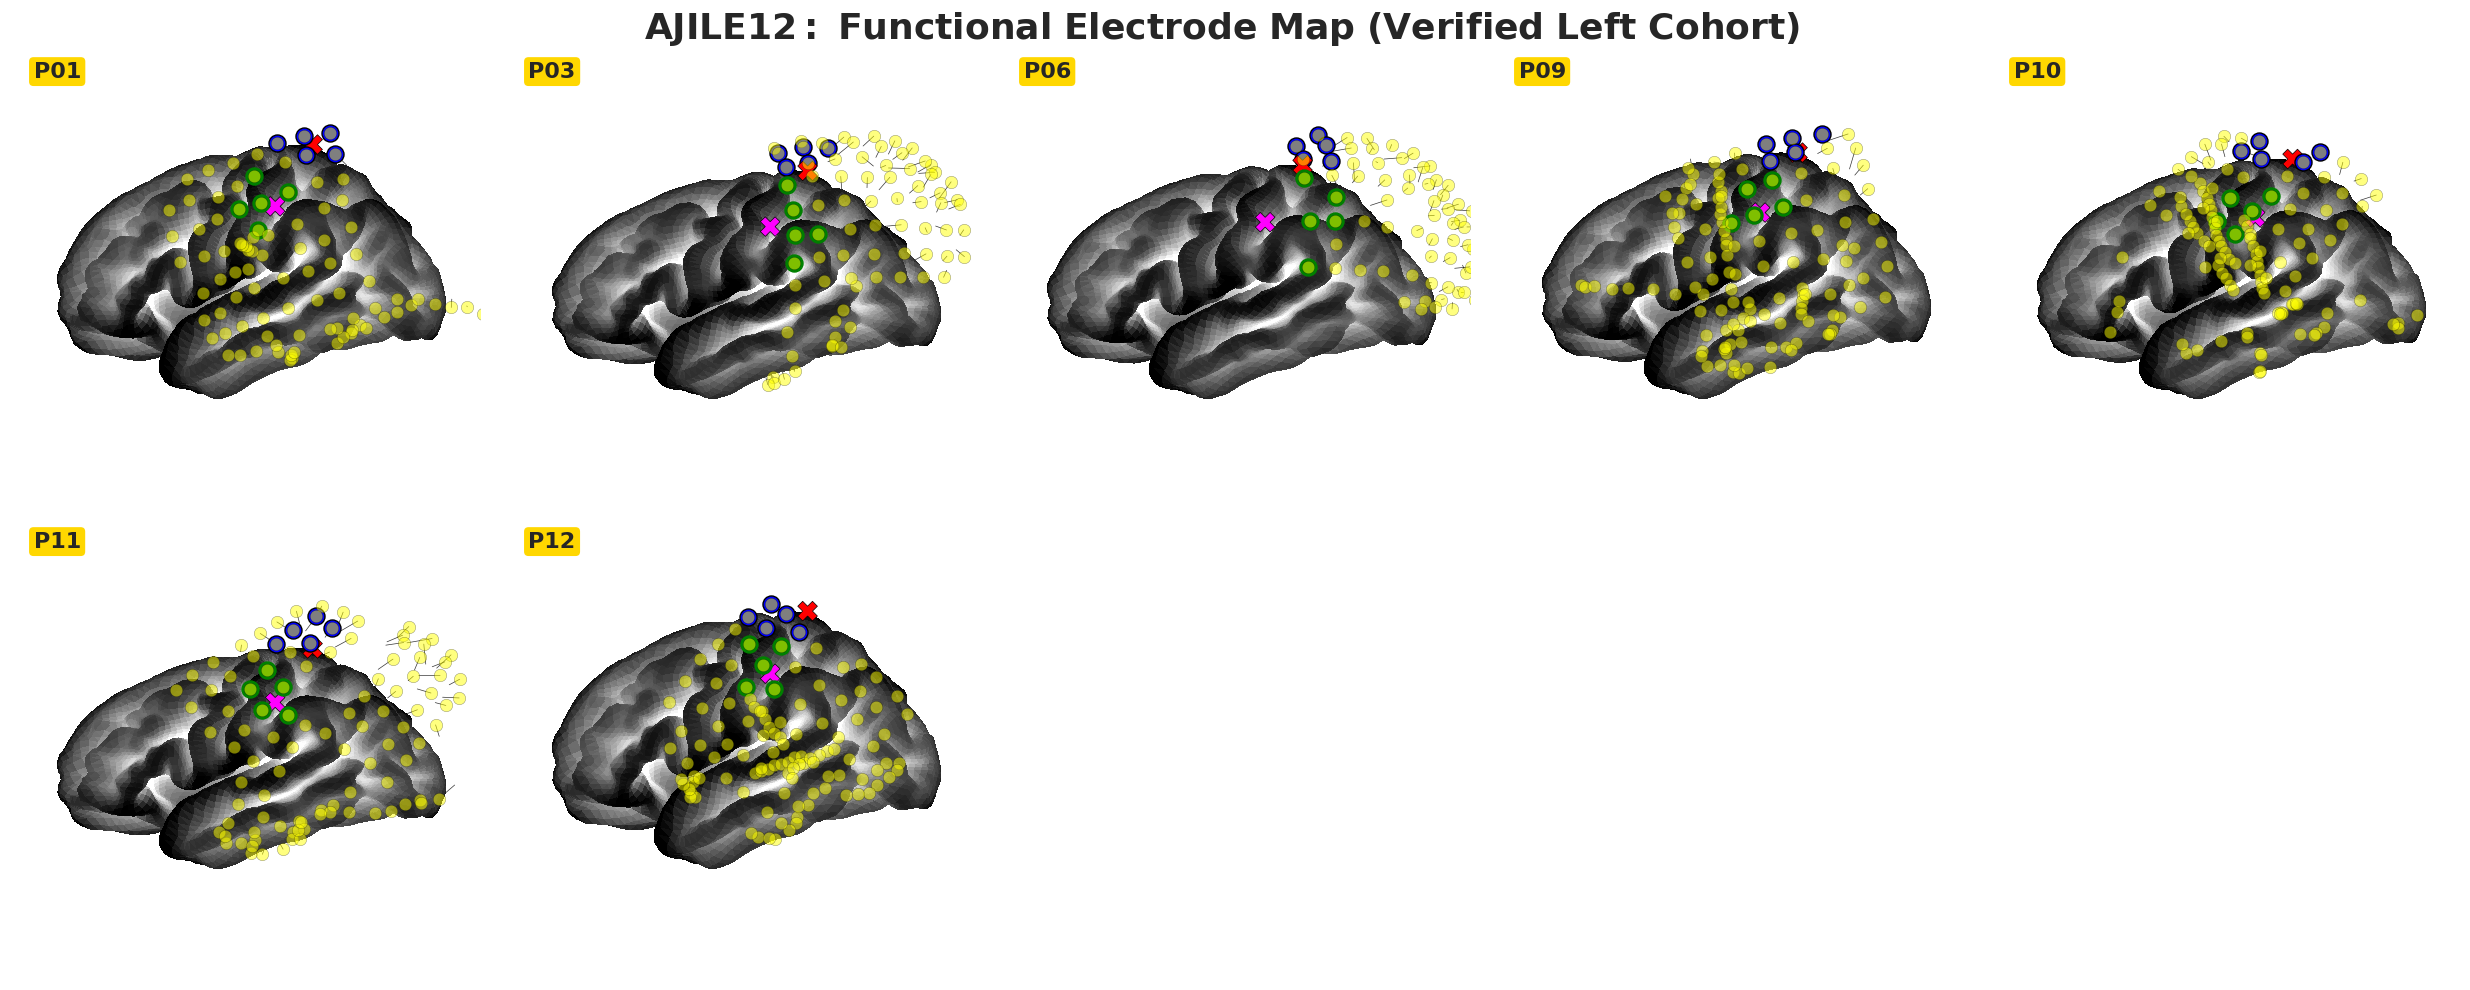

In [ ]:
import os
import gc
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.spatial import distance
from nilearn import datasets, surface, plotting
from dandi.dandiapi import DandiAPIClient
from fsspec.implementations.cached import CachingFileSystem
import fsspec
import h5py
import pynwb
import warnings

warnings.filterwarnings('ignore')

# --- 1. Initialization & Parameters ---
MOTOR_REF  = np.array([-40.0, -22.0, 58.0])
SPEECH_REF = np.array([-54.0,  -6.0, 28.0])

client = DandiAPIClient()
dandiset = client.get_dandiset("000055", "draft")
fs_net = fsspec.filesystem("http")
cached_fs = CachingFileSystem(fs=fs_net, cache_storage="nwb_cache")
fsaverage = datasets.fetch_surf_fsaverage('fsaverage5')

def get_best_elecs(nwb, target_coord, n=5):
    df = nwb.electrodes.to_dataframe()
    mask = (df['good'] == True) & df['x'].notna()
    good = df[mask].copy()
    good['dist'] = np.sqrt((good['x']-target_coord[0])**2 + (good['y']-target_coord[1])**2 + (good['z']-target_coord[2])**2)
    return good.nsmallest(n, 'dist').index.tolist()

def get_surface_points(coords, mesh_vertices):
    coords = np.atleast_2d(coords)
    mesh_vertices = np.atleast_2d(mesh_vertices)
    dists = distance.cdist(coords, mesh_vertices)
    closest_vertex_idx = np.argmin(dists, axis=1)
    return mesh_vertices[closest_vertex_idx]

order = [f"P{str(i).zfill(2)}" for i in range(1, 13)]

# --- 2. CANVAS SETUP ---
# Using a 2x5 grid to safely fit however many true Left patients we find
fig = plt.figure(figsize=(25, 10), facecolor='white')

print("🚀 Scanning Cohort: Dynamically filtering for True Left Hemisphere Patients...")

plot_idx = 1

for p_label in tqdm(order):
    sub_val = int(p_label[1:])
    sub_id = f"sub-{str(sub_val).zfill(2)}"

    assets = list(dandiset.get_assets_with_path_prefix(f"{sub_id}/"))
    if not assets: continue
    url = assets[0].get_content_url(follow_redirects=1, strip_query=True)

    try:
        with h5py.File(cached_fs.open(url, "rb")) as f:
            with pynwb.NWBHDF5IO(file=f, mode='r', load_namespaces=True) as io:
                nwb = io.read()
                elec_df = nwb.electrodes.to_dataframe()

                # --- THE FIX: PROPER DYNAMIC DETECTION ---
                if elec_df['x'].isna().all(): continue

                is_left = elec_df['x'].mean() < 0

                # If they are a Right Hemisphere patient, skip them immediately!
                if not is_left:
                    continue

                # Now we know for a fact they are Left Hemisphere. Add subplot.
                ax = fig.add_subplot(2, 5, plot_idx, projection='3d')
                plot_idx += 1

                hemi_str = 'left'
                m_target = MOTOR_REF
                s_target = SPEECH_REF

                m_best = elec_df.loc[get_best_elecs(nwb, m_target, 5)]
                s_best = elec_df.loc[get_best_elecs(nwb, s_target, 5)]
                all_good = elec_df[(elec_df['good'] == True) & elec_df['x'].notna()]

                # B. PLOT SURFACE
                plotting.plot_surf(
                    fsaverage[f'pial_{hemi_str}'],
                    surf_map=fsaverage[f'sulc_{hemi_str}'],
                    view='lateral',
                    hemi=hemi_str,
                    axes=ax,
                    cmap='gray', alpha=0.15, vmax=1, vmin=-1, colorbar=False
                )

                # C. PLOT ELECTRODES
                mesh_data = surface.load_surf_mesh(fsaverage[f'pial_{hemi_str}'])
                vertices = mesh_data[0]

                if not all_good.empty:
                    all_coords = all_good[['x', 'y', 'z']].values
                    ground_pts = get_surface_points(all_coords, vertices)

                    for orig, ground in zip(all_coords, ground_pts):
                        ax.plot([orig[0], ground[0]],
                                [orig[1], ground[1]],
                                [orig[2], ground[2]],
                                color='black', alpha=0.8, linewidth=0.5, zorder=1)

                ax.scatter(all_good['x'], all_good['y'], all_good['z'],
                           facecolors='yellow', edgecolors='black', s=80, linewidths=0.3,
                           alpha=0.5, depthshade=False)

                ax.scatter(m_best['x'], m_best['y'], m_best['z'],
                           color='blue', s=150, edgecolors='black', linewidths=1,
                           depthshade=False)
                ax.scatter(s_best['x'], s_best['y'], s_best['z'],
                           color='green', s=150, edgecolors='green', linewidths=1,
                           depthshade=False)

                ax.scatter([m_target[0], s_target[0]], [m_target[1], s_target[1]], [m_target[2], s_target[2]],
                           c=['red', 'magenta'], marker='X', s=200, edgecolors='black',
                           linewidths=0.5, depthshade=False)

                # D. LABEL & CLEANUP
                ax.text2D(0.05, 0.92, p_label, transform=ax.transAxes,
                          fontsize=16, fontweight='bold',
                          bbox=dict(facecolor='#FFD700', edgecolor='none', boxstyle='round,pad=0.2'))

                ax.set_axis_off()

        gc.collect()

    except Exception as e:
        print(f"  -> Error on {sub_id}: {e}")

plt.subplots_adjust(wspace=0, hspace=0, left=0.01, right=1, top=0.95, bottom=0.01)
plt.suptitle(r"$\bf{AJILE12:\ Functional\ Electrode\ Map\ (Verified\ Left\ Cohort)}$", fontsize=26, y=0.98)
plt.show()